## Лабораторная работа №6
### Transfer Learning, Oxford Flowers 102

Базовая модель — ResNet50 (`IMAGENET1K_V2`). Обучение в две стадии: сначала только новая голова при замороженном backbone, затем fine-tuning `layer4` + `fc` с малым lr.

Полный пайплайн — в `Lab6_transfer_train.ipynb` (Colab GPU) и `Lab6_transfer_infer.ipynb` (локальный инференс и метрики).

### Кривые обучения

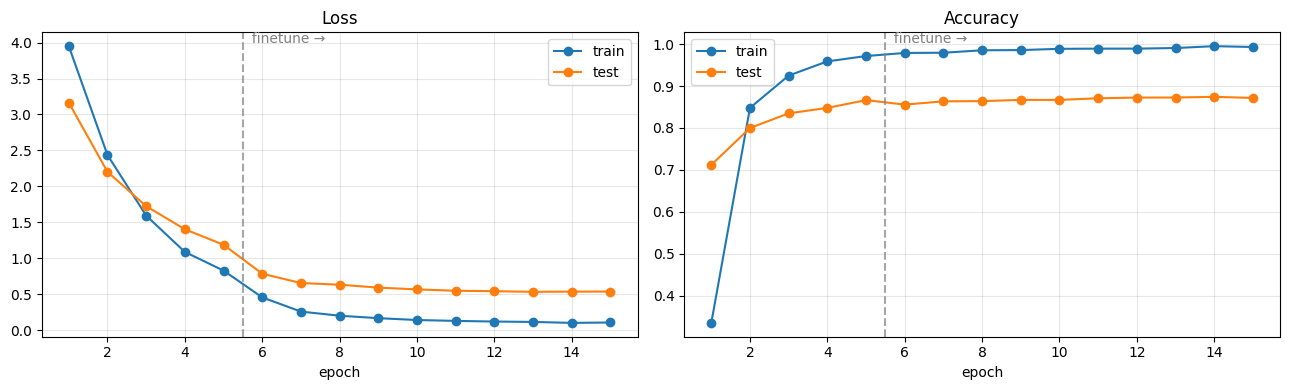

Лучшая test accuracy: 0.8743
Финальная test accuracy: 0.8717


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('history.json') as f:
    history = json.load(f)

epochs = np.arange(1, len(history['train_loss']) + 1)
switch = history['stage'].index('finetune') + 1 if 'finetune' in history.get('stage', []) else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, history['train_loss'], label='train', marker='o')
axes[0].plot(epochs, history['test_loss'],  label='test',  marker='o')
axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs, history['train_acc'], label='train', marker='o')
axes[1].plot(epochs, history['test_acc'],  label='test',  marker='o')
axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
if switch is not None:
    for ax in axes:
        ax.axvline(switch - 0.5, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show()

print(f'best test acc: {max(history["test_acc"]):.4f}')
print(f'final test acc: {history["test_acc"][-1]:.4f}')
